# Amazon_Reviews (Dessertation Project)

In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
## •	pandas: used to handle your dataset (reading, writing, applying functions).
## •	re: stands for Regular Expressions, used to find and remove unwanted patterns (like punctuation or numbers).
## •	nltk: Natural Language Toolkit — a library for text processing tasks.
## •	stopwords: a list of common English words like the, is, at, on, etc.
## •	WordNetLemmatizer: helps reduce words to their base form (e.g. playing → play). 

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alokrai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/alokrai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
fname = "amazon_reviews.csv"

In [5]:
try:
    df = pd.read_csv(fname)
except Exception as e:
    df = pd.read_excel(fname) 

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

First 3 rows:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1      Not as Advertised  Product arrived labeled as Jumbo Salted Peanut...  
2  "Delight" says it all  Th

In [7]:
for col in ['reviewText', 'Text', 'Review', 'Summary', 'Review', 'ReviewText']:
    if col in df.columns:
        text_col = col
        break
else:
    text_col = None

In [8]:
for col in ['rating','Score','stars','overall','Rating']:
    if col in df.columns:
        rating_col = col
        break
else:
    text_col = None

In [9]:
## checking Rating Distributions ##

if rating_col:
    print("\nRating distribution:")
    print(df[rating_col].value_counts().sort_index())


Rating distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [10]:
## checking Text Lengths ## 

if text_col:
    df['txt_len'] = df[text_col].astype(str).str.len()
    print("\nText length stats (chars):")
    print(df['txt_len'].describe())


Text length stats (chars):
count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: txt_len, dtype: float64


What results tell us
	1.	Rating Distribution
	•	5-star reviews: 363,122 (the majority)
	•	1-star reviews: 52,268
    
→ The dataset is highly imbalanced, meaning most people give positive reviews.
	2.	Text Length
	•	Average review: ~436 characters
	•	Shortest: 12 characters
	•	Longest: 21,409 characters
→ So, some reviews are extremely long (might be outliers).

Text Cleaning & Preprocessing

Before we train any model, we need to clean the text data so the machine learning model can understand it.

We’ll do 5 steps:
	1.	Lowercase all words
	2.	Remove punctuation, special characters, and numbers
	3.	Remove extra spaces
	4.	Remove stopwords (like “the”, “is”, “and”)
	5.	Lemmatize (convert words to base form — e.g., loved → love, running → run)

In [11]:
# Step 1: Create an instance of the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Step 2: Define a function for text cleaning
def clean_text(text):
    """
    This function cleans review text by:
    1. Lowercasing all words
    2. Removing numbers, punctuation, and special characters
    3. Removing stopwords (common useless words)
    4. Lemmatizing each word (reducing to base form)
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove numbers, punctuation, and special characters
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Tokenize (split sentence into words)
    words = text.split()
    
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    words = [word for word in words if word not in stop_words]
    
    # Lemmatize each word
    words = [lemmatizer.lemmatize(word) for word in words]
    
    # Join cleaned words back into a sentence
    return ' '.join(words)

# Step 3: Apply the function to your text column
df['cleaned_text'] = df['Text'].astype(str).apply(clean_text)

# Step 4: Preview a few original and cleaned texts
print(df[['Text', 'cleaned_text']].head(5))

                                                Text  \
0  I have bought several of the Vitality canned d...   
1  Product arrived labeled as Jumbo Salted Peanut...   
2  This is a confection that has been around a fe...   
3  If you are looking for the secret ingredient i...   
4  Great taffy at a great price.  There was a wid...   

                                        cleaned_text  
0  bought several vitality canned dog food produc...  
1  product arrived labeled jumbo salted peanutsth...  
2  confection around century light pillowy citrus...  
3  looking secret ingredient robitussin believe f...  
4  great taffy great price wide assortment yummy ...  


“Lemmatization ensures that different forms of the same word are treated as one feature, which improves model accuracy.”

In [12]:
df.to_csv("amazon_cleaned.csv", index=False)

In [13]:
import pandas as pd

df = pd.read_csv("amazon_cleaned.csv")
print(df.columns)
df.head()

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text', 'txt_len',
       'cleaned_text'],
      dtype='object')


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,txt_len,cleaned_text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,263,bought several vitality canned dog food produc...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,190,product arrived labeled jumbo salted peanutsth...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,509,confection around century light pillowy citrus...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,219,looking secret ingredient robitussin believe f...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,140,great taffy great price wide assortment yummy ...


— Feature Extraction (TF-IDF)

Why this step matters:

Machines can’t read text directly — they understand numbers, not words.
So, we need to convert each review into a numerical vector that represents how important each word is.

We’ll use TF-IDF (Term Frequency–Inverse Document Frequency), which:
	•	Gives more weight to words that appear frequently in one review,
	•	But less weight to words that appear too often across all reviews (like “product”, “good”, “buy”).

# Step 1. Feature Extraction (TF-IDF)

In [14]:
df['cleaned_text'] = df['cleaned_text'].fillna("")

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert text into numerical features
tfidf = TfidfVectorizer(max_features=2000, stop_words='english')
X = tfidf.fit_transform(df['cleaned_text'])
y = df['Score']
X.shape

(568454, 2000)

limited TF-IDF to 2000 features for efficiency and removed stopwords so only meaningful words are converted into numerical features.

X contains the features (TF-IDF vectors) independent variable, and y contains the target variable (dependent variable) — the star rating.


# Step 2 — Sentiment Analysis using TextBlob

We’ll use TextBlob, a simple NLP library that can analyze text and return a sentiment polarity score for each review.

In [16]:
!pip install textblob

In [17]:
import nltk
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /Users/alokrai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/alokrai/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

“Punkt is required for TextBlob to break text into tokens internally.”

'averaged_perceptron_tagger' This resource helps TextBlob understand parts of speech while calculating sentiment.

In [18]:
from textblob import TextBlob

# Apply sentiment polarity
df['sentiment'] = df['cleaned_text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

# View a few examples
df[['cleaned_text', 'sentiment']].head(10)

,cleaned_text,sentiment
0,bought several vitality canned dog food produc...,0.425000
1,product arrived labeled jumbo salted peanutsth...,0.216667
2,confection around century light pillowy citrus...,0.187000
3,looking secret ingredient robitussin believe f...,0.150000
4,great taffy great price wide assortment yummy ...,0.458333
5,got wild hair taffy ordered five pound bag taf...,0.333333
6,saltwater taffy great flavor soft chewy candy ...,0.210000
7,taffy good soft chewy flavor amazing would def...,0.380000
8,right im mostly sprouting cat eat grass love r...,0.428571
9,healthy dog food good digestion also good smal...,0.412500


Explanation
	•	What it does:
Each review is analyzed, and TextBlob assigns a polarity score between -1 and +1:
	•	+1 → very positive
	•	0 → neutral
	•	-1 → very negative

	•	TF-IDF captures “what words are present and how important they are”
	•	Polarity captures “how positive or negative the review is”

# Step 2.1 — Analyze Sentiment Distribution Across Ratings

Let’s now check if our sentiment scores actually match the user ratings (this helps prove our cleaning and extraction worked well).

/var/folders/6t/zzckwfsn3w3dlmp8v434xbkm0000gn/T/ipykernel_28756/2932397318.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Score', y='sentiment', data=df, palette='coolwarm')


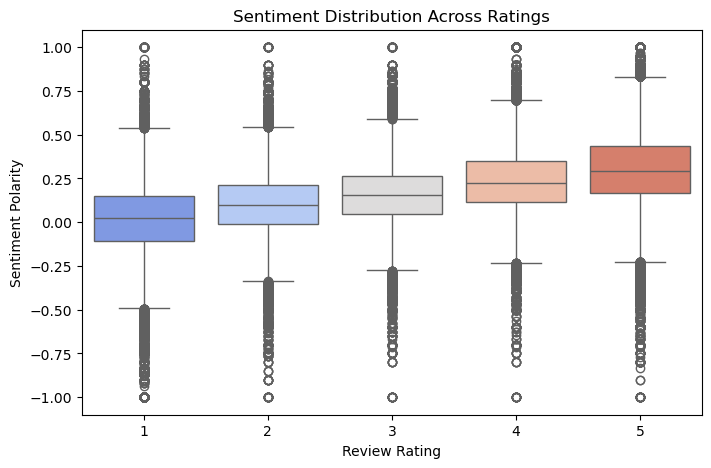

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='Score', y='sentiment', data=df, palette='coolwarm')
plt.title('Sentiment Distribution Across Ratings')
plt.xlabel('Review Rating')
plt.ylabel('Sentiment Polarity')
plt.show()

In this stage, sentiment polarity values were calculated using TextBlob for each review, ranging from –1 (negative) to +1 (positive). A boxplot was created to visualize sentiment distribution across star ratings.

The results show a clear trend — 1-star and 2-star reviews are predominantly negative, 3-star reviews are neutral, and 4-star and 5-star reviews display strong positive sentiment. This suggests that TextBlob effectively captures emotional tone in textual reviews, and the sentiment polarity strongly correlates with user-provided ratings.

This confirms that textual feedback can be used as a reliable predictor of numerical ratings, supporting the next step of model-based prediction.

# Step 2.2: Model Building and Evaluation

Logistic Regression is a simple, interpretable classifier that works well with TF-IDF features.

used train_test_split to separate data into training and testing so I can fairly evaluate my model

spliting the dataset into 80% train and 20% test so that I can train on one part and evaluate on unseen data, which prevents overfitting.

Functions to evaluate model:
	•	accuracy_score → overall correctness
	•	classification_report → precision, recall, F1 per class
	•	confusion_matrix → where the model is getting confused



X = independent variable (features)
	•	Text is converted into TF-IDF numeric matrix.
    
y = dependent variable (target)
	•	Rating (1–5) we want to predict.

used multiclass Logistic Regression with 200 max iterations to ensure convergence with sparse TF-IDF features.

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Prepare data
X = tfidf.fit_transform(df['cleaned_text'].astype(str))   # Convert text to numerical features
y = df['Score']                                           # Target variable

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("Accuracy:", round(accuracy_score(y_test, y_pred), 2))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.72

Classification Report:
               precision    recall  f1-score   support

           1       0.60      0.62      0.61     10326
           2       0.39      0.16      0.22      5855
           3       0.42      0.23      0.30      8485
           4       0.48      0.18      0.27     16123
           5       0.77      0.95      0.85     72902

    accuracy                           0.72    113691
   macro avg       0.53      0.43      0.45    113691
weighted avg       0.67      0.72      0.67    113691


Confusion Matrix:
 [[ 6413   527   414   201  2771]
 [ 1630   914   758   320  2233]
 [ 1005   481  1927  1047  4025]
 [  521   198   882  2971 11551]
 [ 1035   210   567  1663 69427]]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


	•	precision → out of predicted 5★, how many are actually 5★
	•	recall → out of actual 5★, how many we caught
	•	F1-score → balance of precision & recall

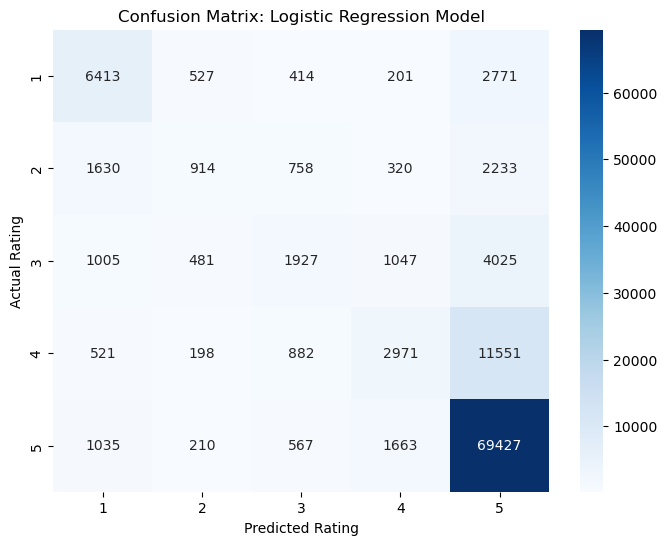

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming y_test are the true ratings and y_pred are your model predictions
cm = confusion_matrix(y_test, y_pred)

# Create the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=[1,2,3,4,5],
            yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted Rating')
plt.ylabel('Actual Rating')
plt.title('Confusion Matrix: Logistic Regression Model')
plt.show()

“The confusion matrix shows that most 5-star ratings are correctly predicted, while confusion mainly happens between neighbouring ratings like 4 and 5 stars.”


# Top Words Driving Ratings

In [27]:
from collections import Counter

# Filter reviews by rating
high_reviews = df[df[rating_col] == 5]['cleaned_text']
low_reviews  = df[df[rating_col] == 1]['cleaned_text']

# Join all words together and split into list of words
high_words = " ".join(high_reviews).split()
low_words  = " ".join(low_reviews).split()

# Count word frequencies
high_counts = Counter(high_words).most_common(20)   # top 20 words for 5-star
low_counts  = Counter(low_words).most_common(20)    # top 20 words for 1-star

print("\nTop words in HIGH (5-star) reviews:")
for word, freq in high_counts:
    print(word, ":", freq)

print("\nTop words in LOW (1-star) reviews:")
for word, freq in low_counts:
    print(word, ":", freq)


Top words in HIGH (5-star) reviews:
br : 13170
like : 12636
love : 11264
great : 11046
good : 10443
one : 10253
taste : 9994
flavor : 9149
tea : 8754
coffee : 8501
food : 8456
product : 8430
get : 6374
make : 6160
dog : 5779
time : 5447
best : 5264
really : 5078
would : 4944
also : 4942

Top words in LOW (1-star) reviews:
br : 2308
product : 2228
like : 2187
taste : 1935
one : 1622
food : 1589
would : 1447
coffee : 1132
flavor : 1041
good : 1016
dog : 999
even : 953
dont : 937
time : 927
get : 906
buy : 905
tea : 837
bag : 833
amazon : 833
really : 742
